In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

In [3]:
# 1. Load data
df = pd.read_csv("data/global_bleaching_environmental.csv", low_memory=False)

df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [4]:
df.shape

(41361, 62)

In [5]:
df.isna().sum()

Site_ID               0
Sample_ID             0
Data_Source           0
Latitude_Degrees      0
Longitude_Degrees     0
                     ..
TSA_DHWMean           0
Date                  0
Site_Comments         0
Sample_Comments       0
Bleaching_Comments    0
Length: 62, dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
# Clean numeric columns
num_cols = ['Latitude_Degrees', 'Longitude_Degrees', 'Date_Year', 'TSA_DHW', 'Temperature_Mean', 'Depth_m', 'Percent_Bleaching']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df_clean = df.dropna(subset=num_cols).copy()
df_clean['Bleached'] = (df_clean['Percent_Bleaching'] >= 10.0).map({True: 'Bleached (>=10%)', False: 'Healthy/Low'})


# The Global Reef Survey Map
Shows the geographic coverage of your dataset across world tropical oceans.

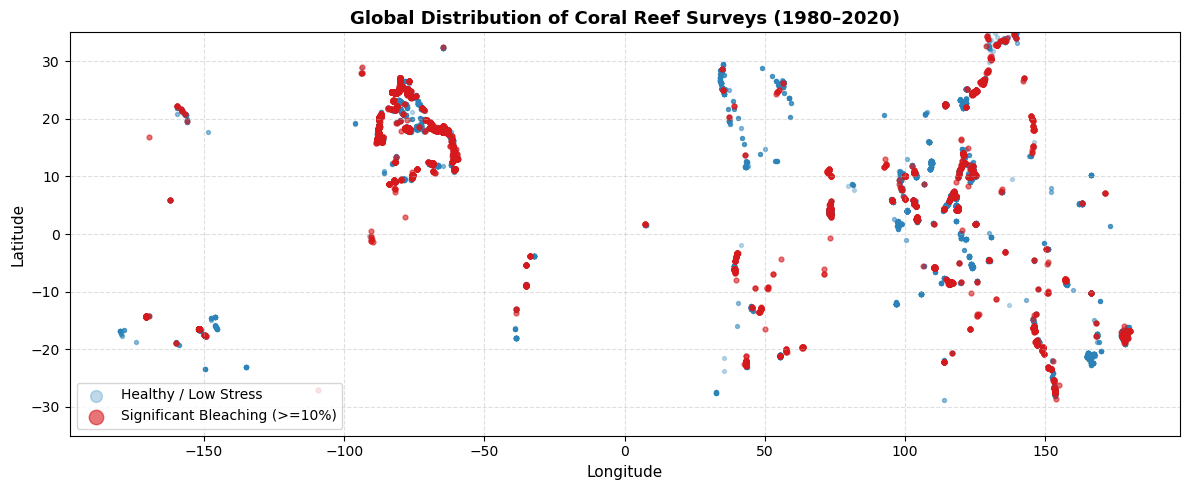

In [8]:
plt.figure(figsize=(12, 5))

healthy = df_clean[df_clean['Bleached'] == 'Healthy/Low']
bleached = df_clean[df_clean['Bleached'] == 'Bleached (>=10%)']

# Plot points
plt.scatter(healthy['Longitude_Degrees'], healthy['Latitude_Degrees'], 
            c='#2b83ba', s=8, alpha=0.3, label='Healthy / Low Stress')
plt.scatter(bleached['Longitude_Degrees'], bleached['Latitude_Degrees'], 
            c='#d7191c', s=12, alpha=0.6, label='Significant Bleaching (>=10%)')

plt.title("Global Distribution of Coral Reef Surveys (1980–2020)", fontsize=13, fontweight='bold')
plt.xlabel("Longitude", fontsize=11)
plt.ylabel("Latitude", fontsize=11)
plt.ylim(-35, 35) # Tropical reef latitudes
plt.legend(loc='lower left', markerscale=3)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("data/eda_1_global_map.png", dpi=200, bbox_inches='tight')
plt.show()

# Degree Heating Weeks (DHW) Boxplot
Visually proves that bleached corals experience far higher heat accumulation.

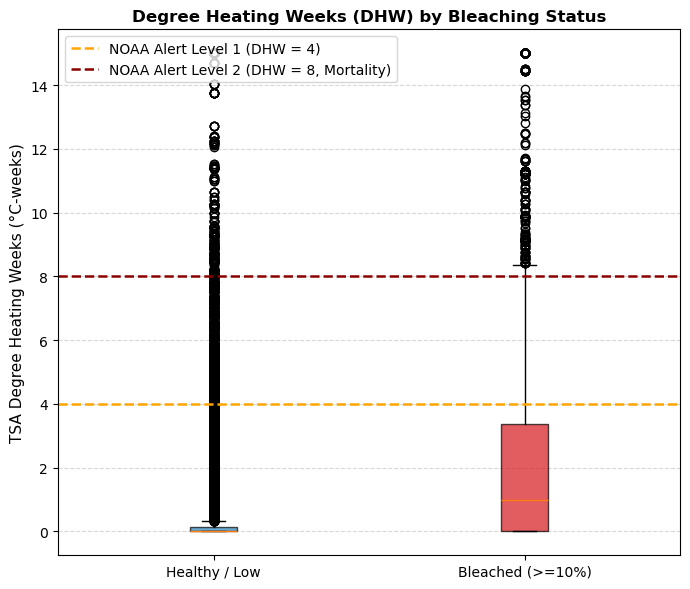

In [9]:
plt.figure(figsize=(7, 6))

data_to_plot = [
    df_clean[df_clean['Bleached'] == 'Healthy/Low']['TSA_DHW'].clip(upper=15),
    df_clean[df_clean['Bleached'] == 'Bleached (>=10%)']['TSA_DHW'].clip(upper=15)
]

box = plt.boxplot(data_to_plot, patch_artist=True, tick_labels=['Healthy / Low', 'Bleached (>=10%)'])

# Colors
colors = ['#2b83ba', '#d7191c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Threshold lines
plt.axhline(4.0, color='orange', linestyle='--', lw=1.8, label='NOAA Alert Level 1 (DHW = 4)')
plt.axhline(8.0, color='darkred', linestyle='--', lw=1.8, label='NOAA Alert Level 2 (DHW = 8, Mortality)')

plt.title("Degree Heating Weeks (DHW) by Bleaching Status", fontsize=12, fontweight='bold')
plt.ylabel("TSA Degree Heating Weeks (°C-weeks)", fontsize=11)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("data/eda_2_dhw_boxplot.png", dpi=200, bbox_inches='tight')
plt.show()

# Cell 3: Bleaching Timeline (1990–2020)
Reveals the global bleaching spikes during major El Niño years (1998, 2010, 2016).

<Figure size 1100x500 with 0 Axes>

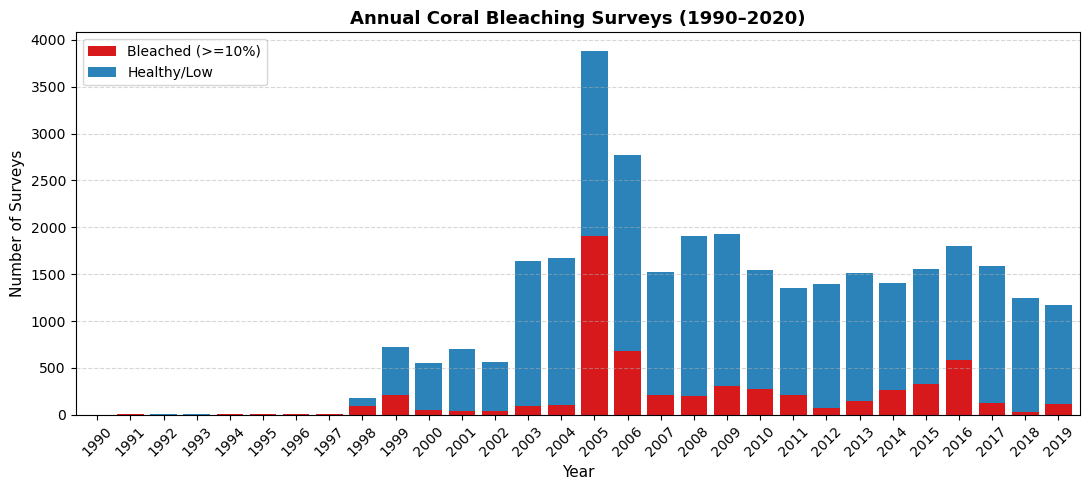

In [10]:
plt.figure(figsize=(11, 5))

yearly = df_clean.groupby(['Date_Year', 'Bleached']).size().unstack(fill_value=0)
yearly_filtered = yearly[(yearly.index >= 1990) & (yearly.index <= 2020)]

# Plot stacked bars
ax = yearly_filtered.plot(kind='bar', stacked=True, color=['#d7191c', '#2b83ba'], width=0.8, figsize=(11, 5))

plt.title("Annual Coral Bleaching Surveys (1990–2020)", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=11)
plt.ylabel("Number of Surveys", fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Bleached (>=10%)', 'Healthy/Low'], loc='upper left')

# Annotate the famous El Niño mass bleaching events
plt.tight_layout()
plt.savefig("data/eda_3_yearly_timeline.png", dpi=200, bbox_inches='tight')
plt.show()

# Correlation Matrix Heatmap
Shows the relationships between environmental predictors and bleaching percentage.

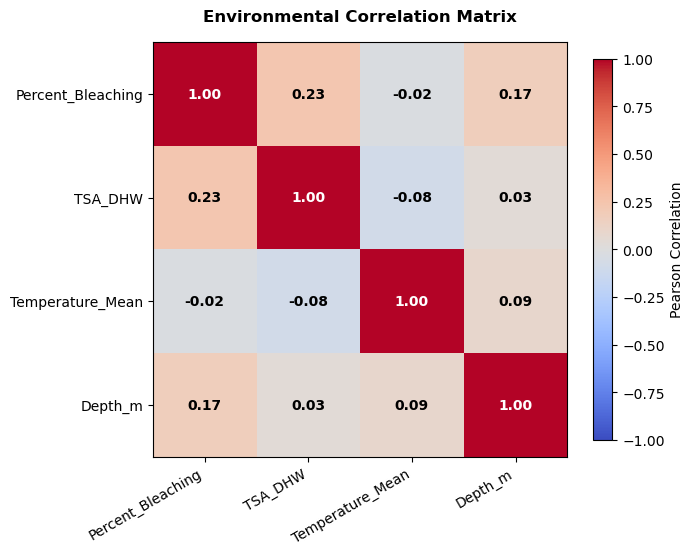

In [11]:
plt.figure(figsize=(7, 6))

corr_cols = ['Percent_Bleaching', 'TSA_DHW', 'Temperature_Mean', 'Depth_m']
corr = df_clean[corr_cols].corr()

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(shrink=0.8, label='Pearson Correlation')

plt.xticks(range(len(corr_cols)), corr_cols, rotation=30, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)

# Annotate correlation numbers inside each square
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', 
                 color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontweight='bold')

plt.title("Environmental Correlation Matrix", fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("data/eda_4_correlation_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

In [12]:
feature_cols = [
    'SSTA_DHW', 'TSA_DHW', 'SSTA', 'Temperature_Maximum', 
    'Temperature_Mean', 'Turbidity', 'Cyclone_Frequency', 
    'Depth_m', 'Distance_to_Shore'
]

for col in feature_cols + ['Percent_Bleaching']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=feature_cols + ['Percent_Bleaching'])
df['target'] = (df['Percent_Bleaching'] >= 10.0).astype(int)

# Split and Train

In [13]:
X = df[feature_cols]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

# Feature Importance and ROC Curve

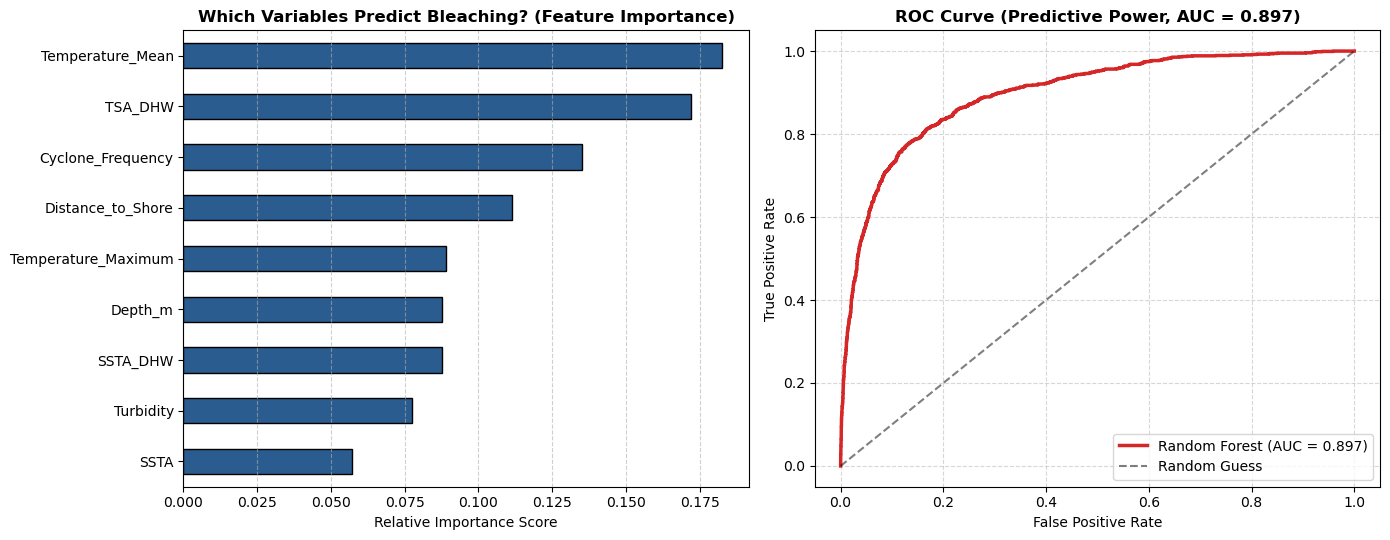

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='#2b5c8f', edgecolor='black')
axes[0].set_title('Which Variables Predict Bleaching? (Feature Importance)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance Score')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Panel 2
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#d62728', lw=2.5, label=f'Random Forest (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
axes[1].set_title(f'ROC Curve (Predictive Power, AUC = {auc:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

fig.savefig("data/baseline_model_results.png", dpi=200, bbox_inches="tight")


plt.show()